<a href="https://colab.research.google.com/github/Jtarazona00/Proyecto_Percepcion/blob/main/notebooks/01_pipeline_completo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto LSP — Pipeline completo en Colab

Notebook end-to-end del proyecto **Reconocimiento de Lengua de Señas Peruana** (UPAO, Percepción Computacional 2026-1).

Este notebook orquesta el pipeline en Colab pero **toda la lógica vive en el repo** (módulos de `src/` + `config.py`). Si actualizas el código en GitHub, basta con re-clonar.

**Flujo:**
1. Clona el repo y configura el entorno.
2. Extrae los `.rar` del dataset VideoLSP10.
3. Procesa frames → keypoints con `src/preprocesamiento/extraer_dataset.py`.
4. Carga y divide el dataset con `src/utils/datos.py`.
5. Entrena baseline SVM con `src/modelos/baseline_svm.py`.
6. Entrena modelo LSTM con `src/entrenamiento/entrenar.py`.
7. Evalúa con `src/evaluacion/evaluar.py`.
8. Guarda `modelo_lsp_final.keras` en Drive.

**Pre-requisitos:**
- Activar **GPU T4** (`Entorno de ejecución` → `Cambiar tipo de hardware` → `T4 GPU`).
- Subir los 6 archivos `rgb.partN.rar` a `Drive/VideoLSP10_rar/`.

## Setup — clonar repo, instalar y montar Drive

In [1]:
# Salir del directorio antes de borrarlo (evita romper el shell cwd)
%cd /content
!rm -rf /content/Proyecto_Percepcion
!git clone https://github.com/Jtarazona00/Proyecto_Percepcion.git /content/Proyecto_Percepcion
%cd /content/Proyecto_Percepcion

# Versiones compatibles: mediapipe 0.10.14 + tensorflow 2.18 (ambos protobuf 4.x)
!apt-get install -y unrar -qq
!pip install -q tensorflow==2.18.0 mediapipe==0.10.14

# Montar Drive y verificar
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')
print('GPU disponible:', tf.config.list_physical_devices('GPU'))
print('TF version:', tf.__version__)

/content
Cloning into '/content/Proyecto_Percepcion'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 69 (delta 25), reused 53 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 26.78 KiB | 8.93 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/Proyecto_Percepcion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 MB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.5.3, so it will not be used.
  warnings.warn(


Mounted at /content/drive
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.18.0


## Paso 1 — Configuración

Las **clases, frames y features** se importan desde `config.py` del repo. Solo definimos aquí las **rutas específicas de Colab/Drive**.

In [2]:
import sys
sys.path.insert(0, '/content/Proyecto_Percepcion')

from pathlib import Path
from config import CLASSES, NUM_CLASSES, FRAMES, FEATURES_PER_FRAME

# Rutas en Drive (ajusta si tienes otras)
RAR_DIR = Path('/content/drive/MyDrive/VideoLSP10_rar')
PROCESSED_DIR_DRIVE = Path('/content/drive/MyDrive/VideoLSP10_processed')
MODELS_DIR_DRIVE = Path('/content/drive/MyDrive/VideoLSP10_models')

# Rutas temporales en disco local de Colab (más rápidas)
LOCAL_RAR = Path('/content/rar_files')
LOCAL_EXTRACTED = Path('/content/rgb_extracted')

for d in (PROCESSED_DIR_DRIVE, MODELS_DIR_DRIVE, LOCAL_RAR, LOCAL_EXTRACTED):
    d.mkdir(parents=True, exist_ok=True)

rars = sorted(RAR_DIR.glob('rgb.part*.rar'))
print(f'{len(rars)} archivos .rar en {RAR_DIR}:')
for r in rars:
    print(f'  - {r.name} ({r.stat().st_size / 1024 / 1024:.0f} MB)')
assert len(rars) == 6, 'Deberías tener exactamente 6 archivos rgb.partN.rar en Drive'
print(f'\n{NUM_CLASSES} clases configuradas en config.py: {CLASSES}')

6 archivos .rar en /content/drive/MyDrive/VideoLSP10_rar:
  - rgb.part1.rar (700 MB)
  - rgb.part2.rar (700 MB)
  - rgb.part3.rar (700 MB)
  - rgb.part4.rar (700 MB)
  - rgb.part5.rar (700 MB)
  - rgb.part6.rar (121 MB)

10 clases configuradas en config.py: ['ayudame', 'por_favor', 'disculpame', 'cual_es_tu_nombre', 'donde_vives_tu', 'no_entiendo', 'que_haces_tu', 'hola_como_estas_tu', 'gracias', 'hasta_manana']


## Paso 2 — Extraer los `.rar` en disco local de Colab

Copia los `.rar` de Drive al disco temporal de Colab (más rápido) y los descomprime. Tarda 5-15 minutos.

In [3]:
import shutil

for r in rars:
    destino = LOCAL_RAR / r.name
    if not destino.exists():
        shutil.copy(r, destino)
        print(f'  copiado: {r.name}')

print('\nExtrayendo (5-15 min)...')
!unrar x -o+ "{LOCAL_RAR}/rgb.part1.rar" "{LOCAL_EXTRACTED}/" > /tmp/unrar.log 2>&1 && echo '   OK' || (echo '   ERROR:'; tail -20 /tmp/unrar.log)

  copiado: rgb.part1.rar
  copiado: rgb.part2.rar
  copiado: rgb.part3.rar
  copiado: rgb.part4.rar
  copiado: rgb.part5.rar
  copiado: rgb.part6.rar

Extrayendo (5-15 min)...
   OK


## Paso 3 — Procesar frames → keypoints con MediaPipe

Toda la lógica vive en `src/preprocesamiento/extraer_dataset.py`. El notebook solo invoca la función y le pasa rutas.

**Es resumible**: si Colab se desconecta, al re-ejecutar continúa donde quedó (los `.npy` se guardan directo en Drive).

In [8]:
from src.preprocesamiento.extraer_dataset import parse_nombre_carpeta, procesar_dataset

# Detectar la carpeta donde estan las secuencias <clase>_r.<id>/
candidatos = [LOCAL_EXTRACTED] + [p for p in LOCAL_EXTRACTED.iterdir() if p.is_dir()]
BASE_RGB = None
for c in candidatos:
    for sub in c.iterdir():
        if sub.is_dir() and parse_nombre_carpeta(sub.name)[0] in CLASSES:
            BASE_RGB = c
            break
    if BASE_RGB:
        break

assert BASE_RGB is not None, 'No se encontraron carpetas <clase>_r.<id>/'
print(f'Carpeta base detectada: {BASE_RGB}')

# Procesar todo (resumible)
procesar_dataset(BASE_RGB, salida=PROCESSED_DIR_DRIVE)

Carpeta base detectada: /content/rgb_extracted
Pendientes: 600 secuencias


MediaPipe:   0%|          | 0/600 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
MediaPipe: 100%|██████████| 600/600 [25:52<00:00,  2.59s/it]

Extraccion completa.


## Paso 4 — Cargar dataset y split estratificado 80/10/10

Usa `src/utils/datos.py`.

In [9]:
from src.utils.datos import cargar_dataset, particionar

X, y = cargar_dataset(processed_dir=PROCESSED_DIR_DRIVE)
print(f'Dataset cargado: X={X.shape}, y={y.shape}')

X_train, X_val, X_test, y_train, y_val, y_test = particionar(X, y)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Dataset cargado: X=(600, 30, 258), y=(600,)
Train: (479, 30, 258), Val: (61, 30, 258), Test: (60, 30, 258)


## Paso 5 — Baseline SVM (Sección 4.1)

Usa `src/modelos/baseline_svm.py`: features estadísticas (media + std + rango → 774) + SVM RBF.

In [10]:
from src.modelos.baseline_svm import features_dataset, entrenar_svm

X_train_stats = features_dataset(X_train)
X_test_stats  = features_dataset(X_test)

svm, scaler, precision_baseline = entrenar_svm(
    X_train_stats, y_train, X_test_stats, y_test
)

Precisión Baseline SVM: 85.00%


## Paso 6 — Entrenar modelo LSTM (Secciones 4.2 y 4.3)

Arquitectura definida en `src/modelos/lstm_modelo.py`. Entrenamiento (Adam 0.0005, 100 épocas, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau) en `src/entrenamiento/entrenar.py`.

In [11]:
from src.entrenamiento.entrenar import entrenar

model, historial = entrenar(X_train, y_train, X_val, y_val)

Epoch 1/100
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0665 - loss: 2.3139
Epoch 1: val_accuracy improved from None to 0.13115, saving model to modelo_lsp_final.keras

Epoch 1: finished saving model to modelo_lsp_final.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.0960 - loss: 2.3191 - val_accuracy: 0.1311 - val_loss: 2.2882 - learning_rate: 5.0000e-04
Epoch 2/100
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0922 - loss: 2.3079
Epoch 2: val_accuracy improved from 0.13115 to 0.24590, saving model to modelo_lsp_final.keras

Epoch 2: finished saving model to modelo_lsp_final.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1148 - loss: 2.2924 - val_accuracy: 0.2459 - val_loss: 2.2475 - learning_rate: 5.0000e-04
Epoch 3/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1672 - loss: 2.2557
Epoch 3: val_accuracy did not improve from 0.24590
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1733 - loss: 2.2344 - val_accuracy: 0.2131 - v

## Paso 7 — Evaluación (Sección 5)

Usa `src/evaluacion/evaluar.py`.

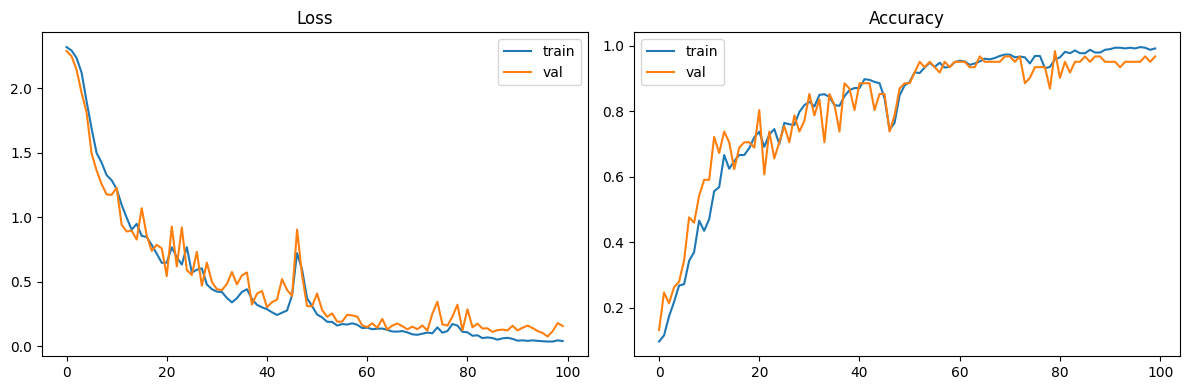

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
                    precision    recall  f1-score   support

           ayudame       0.60      0.50      0.55         6
         por_favor       1.00      0.83      0.91         6
        disculpame       0.62      0.83      0.71         6
 cual_es_tu_nombre       1.00      0.83      0.91         6
    donde_vives_tu       0.75      0.50      0.60         6
       no_entiendo       1.00      1.00      1.00         6
      que_haces_tu       1.00      1.00      1.00         6
hola_como_estas_tu       0.86      1.00      0.92         6
           gracias       0.86      1.00      0.92         6
      hasta_manana       0.71      0.83      0.77         6

          accuracy                           0.83        60
         macro avg       0.84      0.83      0.83        60
      weighted avg       0.84      0.83      0.83        60



<Figure size 640x480 with 0 Axes>

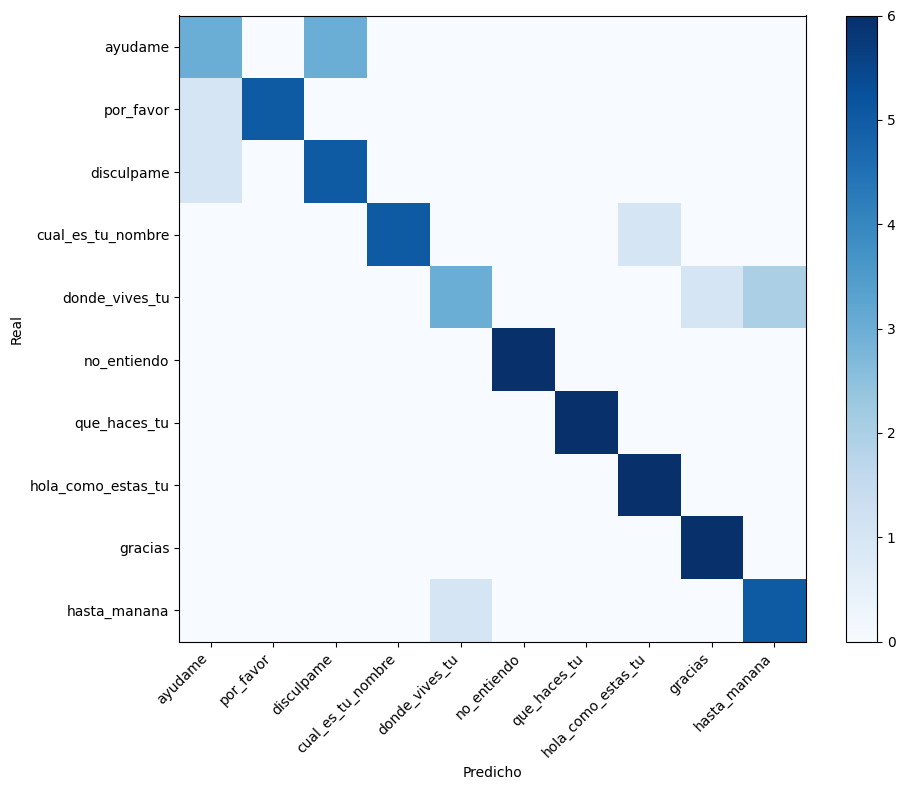


=== Comparacion ===
  Baseline SVM: 85.00%
  Modelo LSTM:  83.33%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from src.evaluacion.evaluar import evaluar_modelo, matriz_confusion, graficar_historial

graficar_historial(historial)
plt.savefig('curvas_aprendizaje.png', dpi=120, bbox_inches='tight')

y_pred = evaluar_modelo(model, X_test, y_test)
matriz_confusion(y_test, y_pred, guardar='matriz_confusion.png')

precision_lstm = float((y_pred == y_test).mean())
print(f'\n=== Comparacion ===')
print(f'  Baseline SVM: {precision_baseline:.2%}')
print(f'  Modelo LSTM:  {precision_lstm:.2%}')

## Paso 8 — Guardar modelo y gráficas en Drive

In [13]:
import shutil

modelo_final = MODELS_DIR_DRIVE / 'modelo_lsp_final.keras'
shutil.copy('modelo_lsp_final.keras', modelo_final)
shutil.copy('curvas_aprendizaje.png', MODELS_DIR_DRIVE / 'curvas_aprendizaje.png')
shutil.copy('matriz_confusion.png',  MODELS_DIR_DRIVE / 'matriz_confusion.png')

print(f'Modelo y graficas guardados en: {MODELS_DIR_DRIVE}')

from google.colab import files
files.download(str(modelo_final))

Modelo y graficas guardados en: /content/drive/MyDrive/VideoLSP10_models


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from pathlib import Path

PROCESSED_DIR_DRIVE = Path('/content/drive/MyDrive/VideoLSP10_processed')
LOCAL_EXTRACTED = Path('/content/rgb_extracted')

# 1. ¿Se extrajeron los .rar?
print('=== EXTRACCION DE RAR ===')
print(f'Carpeta /content/rgb_extracted existe? {LOCAL_EXTRACTED.exists()}')
if LOCAL_EXTRACTED.exists():
    items = sorted(LOCAL_EXTRACTED.iterdir())
    print(f'Total items: {len(items)}')
    print(f'Primeros 5: {[i.name for i in items[:5]]}')
    print(f'Ultimos 5: {[i.name for i in items[-5:]]}')

# 2. ¿Se procesaron a .npy?
print('\n=== PROCESADO A .NPY ===')
print(f'Carpeta Drive existe? {PROCESSED_DIR_DRIVE.exists()}')
if PROCESSED_DIR_DRIVE.exists():
    total = 0
    for clase in sorted(PROCESSED_DIR_DRIVE.iterdir()):
        if clase.is_dir():
            n = len(list(clase.glob('*.npy')))
            total += n
            print(f'  {clase.name}: {n} archivos .npy')
    print(f'  TOTAL: {total}')

# 3. ¿Hay log de unrar?
print('\n=== LOG UNRAR ===')
import os
if os.path.exists('/tmp/unrar.log'):
    !tail -30 /tmp/unrar.log
else:
    print('No existe /tmp/unrar.log')

=== EXTRACCION DE RAR ===
Carpeta /content/rgb_extracted existe? True
Total items: 600
Primeros 5: ['ayudame_r.1', 'ayudame_r.10', 'ayudame_r.11', 'ayudame_r.12', 'ayudame_r.13']
Ultimos 5: ['que_haces_tu_r.6', 'que_haces_tu_r.60', 'que_haces_tu_r.7', 'que_haces_tu_r.8', 'que_haces_tu_r.9']

=== PROCESADO A .NPY ===
Carpeta Drive existe? True
  ayudame: 60 archivos .npy
  cual_es_tu_nombre: 60 archivos .npy
  disculpame: 60 archivos .npy
  donde_vives_tu: 60 archivos .npy
  gracias: 60 archivos .npy
  hasta_manana: 60 archivos .npy
  hola_como_estas_tu: 60 archivos .npy
  no_entiendo: 60 archivos .npy
  por_favor: 60 archivos .npy
  que_haces_tu: 60 archivos .npy
  TOTAL: 600

=== LOG UNRAR ===
Extracting  /content/rgb_extracted/ayudame_r.5/73.Jpg                     99%  OK 
Extracting  /content/rgb_extracted/ayudame_r.5/74.Jpg                     99%  OK 
Extracting  /content/rgb_extracted/ayudame_r.5/75.Jpg                     99%  OK 
Extracting  /content

In [15]:
# Traer el fix del repo
!cd /content/Proyecto_Percepcion && git pull

# Forzar recarga del modulo en memoria
import importlib
import src.preprocesamiento.extraer_dataset as _m
importlib.reload(_m)
from src.preprocesamiento.extraer_dataset import procesar_dataset, parse_nombre_carpeta
print('Fix aplicado en memoria.')

Already up to date.
Fix aplicado en memoria.


In [16]:
import tensorflow as tf
import mediapipe as mp
import cv2
import numpy as np

print(f'TensorFlow: {tf.__version__}')
print(f'MediaPipe:  {mp.__version__}')
print(f'OpenCV:     {cv2.__version__}')
print(f'NumPy:      {np.__version__}')
print(f'GPU:        {tf.config.list_physical_devices("GPU")}')

# Test rápido: ¿MediaPipe Holistic funciona?
with mp.solutions.holistic.Holistic() as h:
    print('MediaPipe Holistic: OK')

TensorFlow: 2.18.0
MediaPipe:  0.10.14
OpenCV:     4.13.0
NumPy:      2.0.2
GPU:        [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
MediaPipe Holistic: OK
